In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
type1_df = pd.read_csv('../../data/df_clean_final_Type1.csv')
type1_df.columns = type1_df.columns.str.strip()

In [49]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Defect_Status',
       'Defect_Type'],
      dtype='str')

In [50]:
type1_df.head()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Defect_Status,Defect_Type
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,...,0.7,0.8,695.0,6.3,26.0,2.71,32.9,58.4,0,Normal
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,Normal
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,0,Normal
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,...,0.7,0.8,696.4,6.3,26.1,2.69,32.9,58.2,1,Exfoliation
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,...,0.7,0.8,697.9,6.4,26.1,2.69,32.9,57.8,0,Normal


In [51]:
cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity']
type1_df['Velocity_minmax'] = type1_df[cols].max(axis=1) - type1_df[cols].min(axis=1)

In [52]:
display(type1_df[['Velocity_minmax']].head()) 
display(type1_df[['Velocity_minmax']].tail())

,Velocity_minmax
0,1.990
1,1.980
2,1.972
3,1.993
4,1.967


,Velocity_minmax
2646,2.0540
2647,2.0750
2648,2.0935
2649,2.0935
2650,2.0910


In [53]:
type1_df['Velocity_diff_1_2'] = type1_df['Velocity_2'] - type1_df['Velocity_1']
type1_df['Velocity_diff_2_3'] = type1_df['Velocity_3'] - type1_df['Velocity_2']
type1_df['Velocity_diff_3_high'] = type1_df['High_Velocity'] - type1_df['Velocity_3']
type1_df['Pressure_Diff_ratio'] = type1_df['Casting_Pressure'] / type1_df['Cylinder_Pressure']


In [54]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Defect_Status',
       'Defect_Type', 'Velocity_minmax', 'Velocity_diff_1_2',
       'Velocity_diff_2_3', 'Velocity_diff_3_high', 'Pressure_Diff_ratio'],
      dtype='str')

In [55]:
type1_df.columns = type1_df.columns.str.strip()

In [56]:
type1_df.describe()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Defect_Status,Velocity_minmax,Velocity_diff_1_2,Velocity_diff_2_3,Velocity_diff_3_high,Pressure_Diff_ratio
count,2.651000e+03,2651.0,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,...,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000
mean,1.780173e+06,1.0,545.038853,0.143093,0.168662,0.182098,2.138724,219.157299,0.008046,11.659751,...,26.766730,2.708167,33.523123,58.350170,0.217276,1.995631,0.025569,0.013436,1.956625,4.840089
std,1.259517e+06,0.0,356.391019,0.003332,0.003721,0.005717,0.026491,7.462748,0.001414,1.169598,...,0.472594,0.042578,1.917431,7.759591,0.412470,0.024822,0.002540,0.004430,0.024503,0.008111
min,1.000000e+00,1.0,1.000000,0.138000,0.164000,0.174000,2.082000,214.000000,0.005000,6.000000,...,25.900000,2.590000,30.600000,45.500000,0.000000,1.936000,0.018000,0.002000,1.892000,4.748954
25%,6.631695e+05,1.0,229.000000,0.142000,0.168000,0.178000,2.122000,215.000000,0.008000,11.000000,...,26.400000,2.690000,32.000000,50.500000,0.000000,1.979000,0.024000,0.010000,1.941000,4.834862
50%,1.551227e+06,1.0,516.000000,0.142000,0.168000,0.182000,2.137000,217.000000,0.008000,12.000000,...,26.800000,2.710000,32.500000,61.700000,0.000000,1.995000,0.026000,0.014000,1.956000,4.841004
75%,2.877004e+06,1.0,842.000000,0.144000,0.170000,0.185000,2.153000,218.000000,0.008000,12.000000,...,27.150000,2.740000,35.400000,64.200000,0.000000,2.010000,0.027000,0.017000,1.971000,4.845794
max,4.205745e+06,1.0,1296.000000,0.163000,0.190000,0.210000,2.256500,239.000000,0.021000,15.000000,...,28.100000,2.790000,37.000000,70.700000,1.000000,2.106500,0.040000,0.025000,2.060500,4.935897


In [57]:
type1_df[['Casting_Pressure','Cylinder_Pressure']].describe()

,Casting_Pressure,Cylinder_Pressure
count,2651.000000,2651.000000
mean,1060.735571,219.157299
std,36.010060,7.462748
min,1035.000000,214.000000
25%,1039.000000,215.000000
50%,1052.000000,217.000000
75%,1055.000000,218.000000
max,1159.000000,239.000000


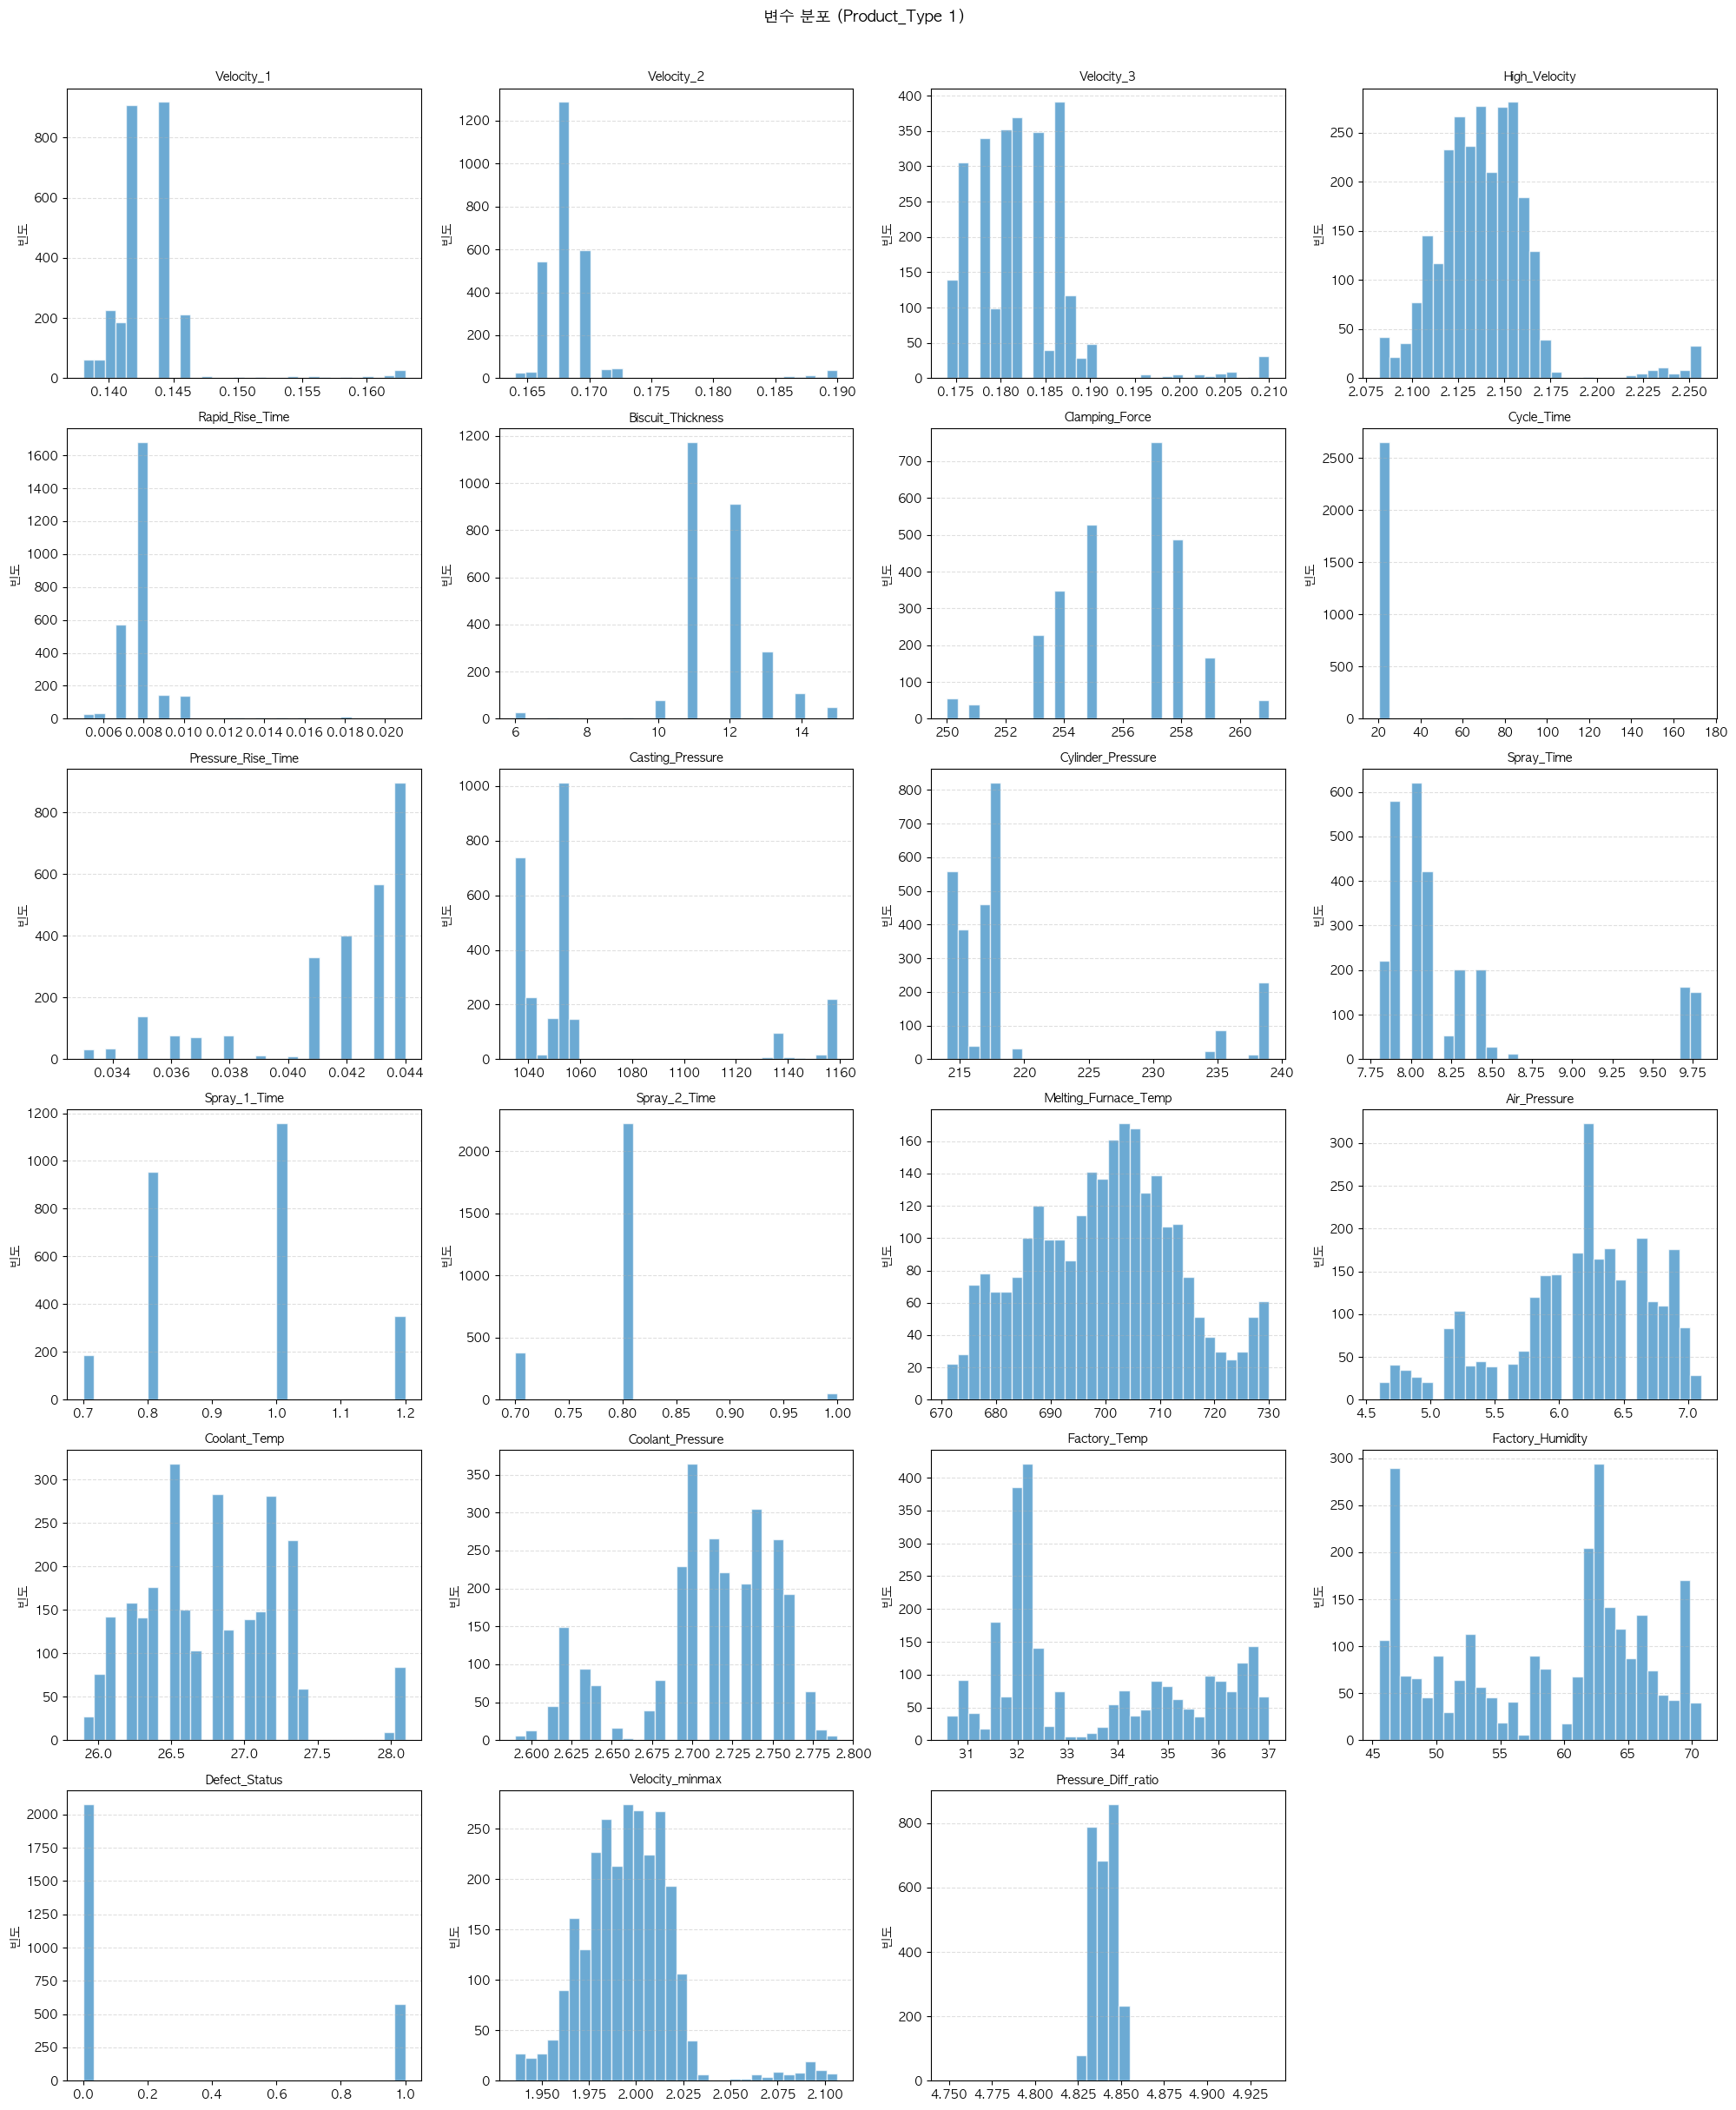

In [58]:
import math

final_vars = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Casting_Pressure',
    'Cylinder_Pressure', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    'Defect_Status', 
    'Defect_Type', 
    'Velocity_minmax', 
    'Pressure_Diff_ratio'
]
# 변수 히스토그램
num_cols = [col for col in final_vars if type1_df[col].dtype in ['int64', 'float64']]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(type1_df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

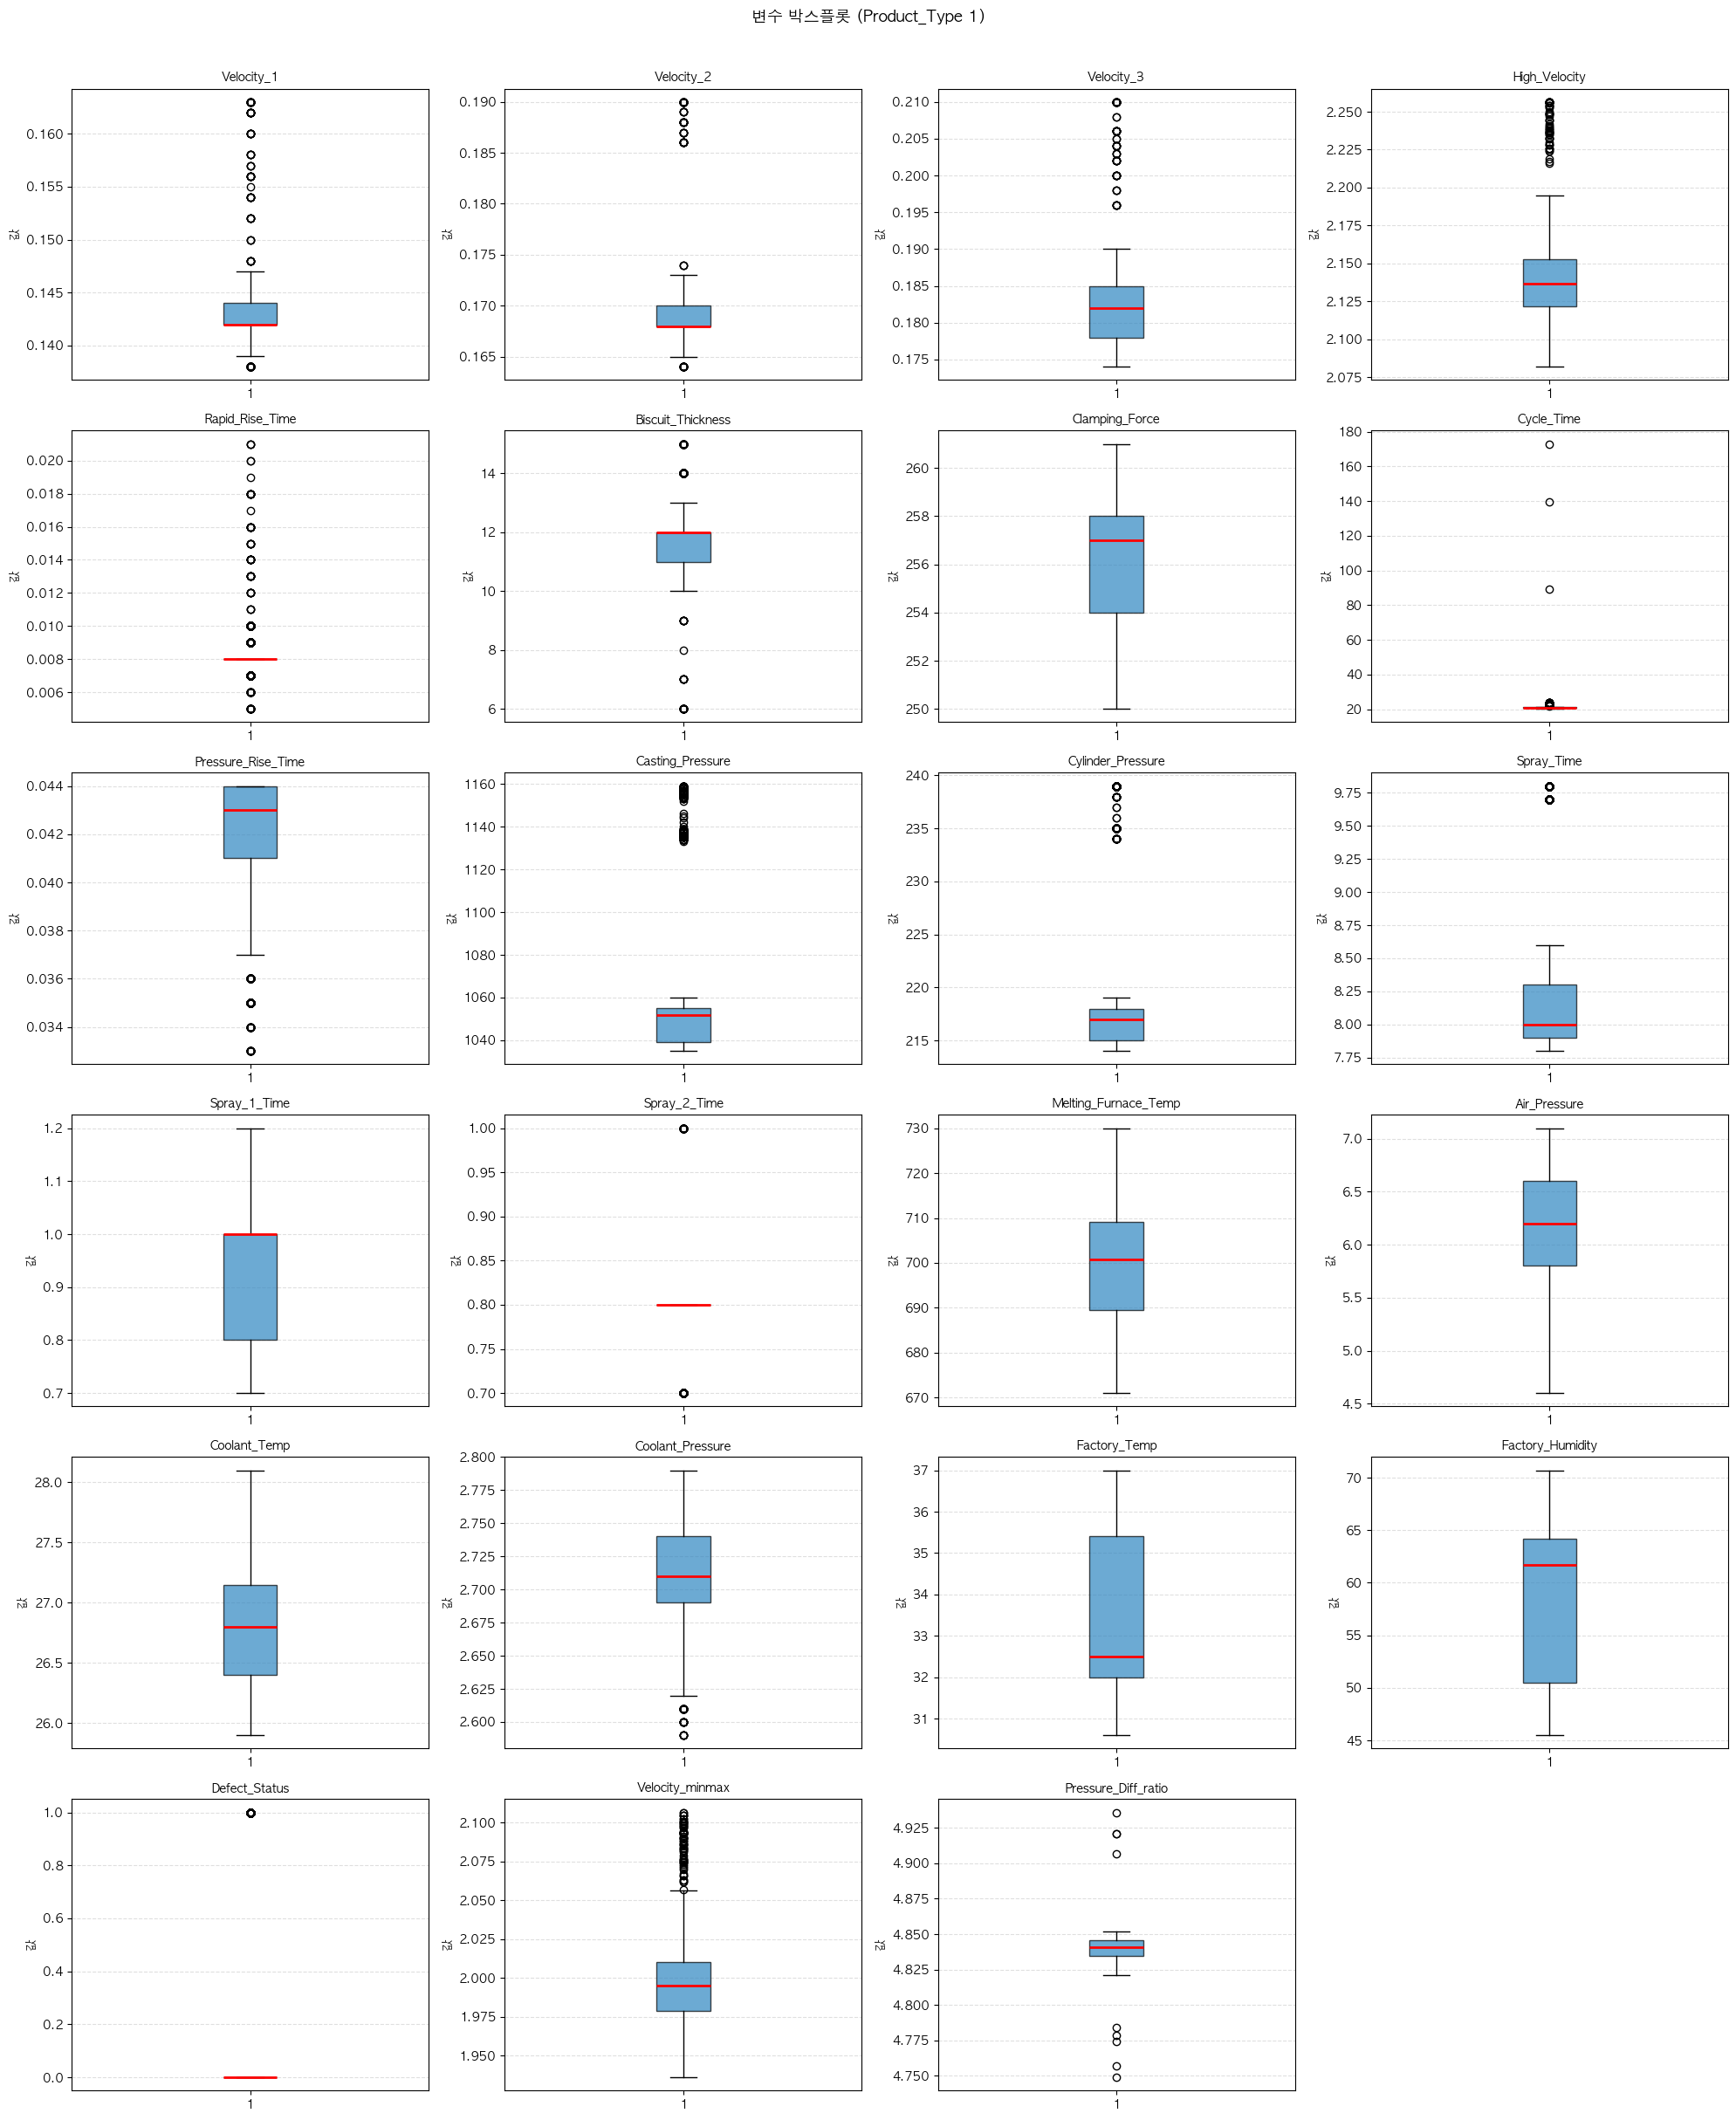

In [59]:
# 변수 박스플롯
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(type1_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2E86C1', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('값')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 박스플롯 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

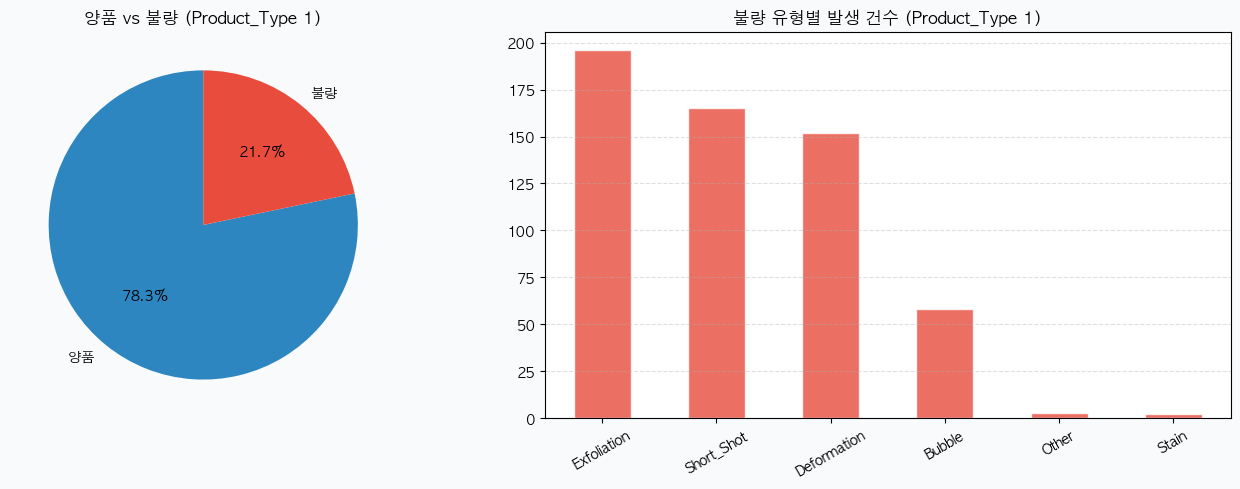

In [60]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = type1_df['Defect_Status'].value_counts().sort_index()
axes[0].pie(sizes, labels=['양품', '불량'], autopct='%1.1f%%',
            colors=['#2E86C1', '#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 1)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = type1_df[type1_df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 1)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [61]:
from scipy.stats import spearmanr

exclude_cols = ['Defect_Status', 'Defect_Type', 'id', 'Product_Type','Velocity_minmax', 'Velocity_diff_1_2',
       'Velocity_diff_2_3', 'Velocity_diff_3_high', 'Pressure_Diff'] 

results = []

for col in type1_df.columns:
    if col in exclude_cols:
        continue
    clean = type1_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4)
    })

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
spearman_df.insert(0, 'rank', range(1, len(spearman_df)+1))
spearman_df = spearman_df.set_index("rank")
display(spearman_df)

,변수,스피어만 상관계수,p-value,절댓값
rank,,,,
1,Factory_Humidity,-0.2782,0.0000,0.2782
2,Factory_Temp,0.2155,0.0000,0.2155
3,Biscuit_Thickness,-0.1698,0.0000,0.1698
4,Spray_2_Time,0.1669,0.0000,0.1669
5,Casting_Pressure,-0.1253,0.0000,0.1253
6,Cylinder_Pressure,-0.1207,0.0000,0.1207
7,Cycle_Time,-0.1204,0.0000,0.1204
8,Pressure_Rise_Time,0.1003,0.0000,0.1003
9,Spray_Time,-0.0968,0.0000,0.0968


In [62]:
high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Diff_ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(type1_df[high_corr_vars].corr().round(3))
print()
print("※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장")
print("  Pressure_Diff = Casting_Pressure - Cylinder_Pressure")
print("  → 두 압력의 차이가 실질적인 정보를 담고 있음")

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Diff_ratio
Casting_Pressure,1.000,0.999,-0.038
Cylinder_Pressure,0.999,1.000,-0.087
Pressure_Diff_ratio,-0.038,-0.087,1.000



※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장
  Pressure_Diff = Casting_Pressure - Cylinder_Pressure
  → 두 압력의 차이가 실질적인 정보를 담고 있음


In [63]:
top10 = spearman_df.head(10).copy()

print("🏆 TOP 10 변수 (상관계수 기준)")
print("-" * 50)

for idx, row in top10.iterrows():   # idx가 rank 인덱스
    direction = "▼ 불량 감소" if row['스피어만 상관계수'] < 0 else "▲ 불량 증가"
    print(f"  #{int(idx):2d}  {row['변수']:<25}  {row['스피어만 상관계수']:+.4f}  {direction}")

🏆 TOP 10 변수 (상관계수 기준)
--------------------------------------------------
  # 1  Factory_Humidity           -0.2782  ▼ 불량 감소
  # 2  Factory_Temp               +0.2155  ▲ 불량 증가
  # 3  Biscuit_Thickness          -0.1698  ▼ 불량 감소
  # 4  Spray_2_Time               +0.1669  ▲ 불량 증가
  # 5  Casting_Pressure           -0.1253  ▼ 불량 감소
  # 6  Cylinder_Pressure          -0.1207  ▼ 불량 감소
  # 7  Cycle_Time                 -0.1204  ▼ 불량 감소
  # 8  Pressure_Rise_Time         +0.1003  ▲ 불량 증가
  # 9  Spray_Time                 -0.0968  ▼ 불량 감소
  #10  Clamping_Force             +0.0798  ▲ 불량 증가


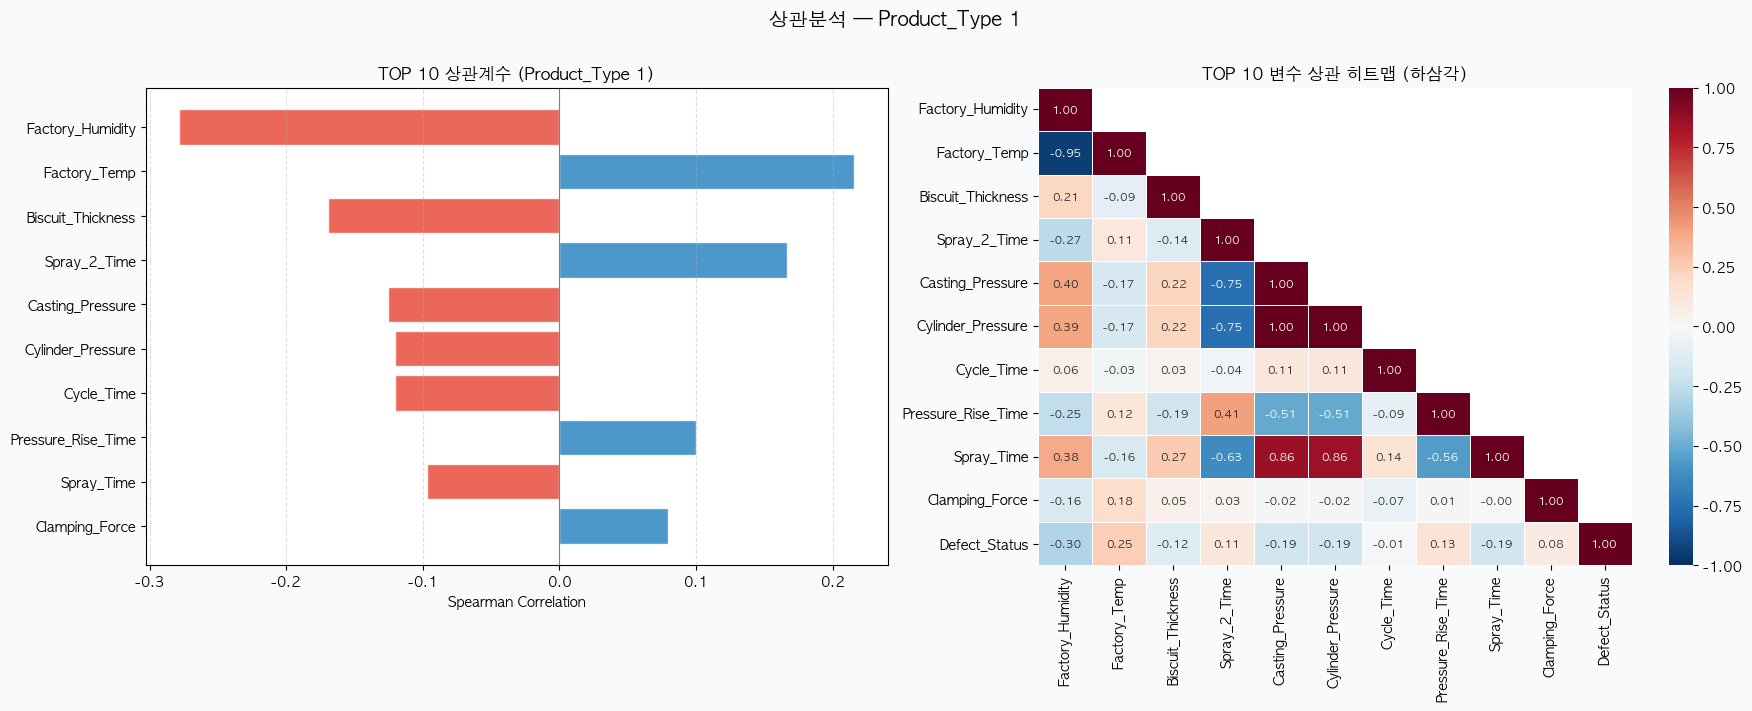

In [64]:
import numpy as np
# 상관계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F8FAFB')

# 바 차트
colors = ['#E74C3C' if v < 0 else '#2E86C1' for v in top10['스피어만 상관계수']]
axes[0].barh(top10['변수'][::-1], top10['스피어만 상관계수'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('TOP 10 상관계수 (Product_Type 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Spearman Correlation')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# 히트맵
top10_vars = top10['변수'].tolist()
corr_matrix = type1_df[top10_vars + ['Defect_Status']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, linewidths=0.5)
axes[1].set_title('TOP 10 변수 상관 히트맵 (하삼각)', fontsize=12, fontweight='bold')

plt.suptitle('상관분석 — Product_Type 1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [65]:
#---------------------
# 1. 정규성 검정
#---------------------
from scipy import stats

target_vars = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    'Casting_Pressure',
    'Cylinder_Pressure',
    'Pressure_Diff_ratio'
]

results = []
for col in target_vars:
    stat, p = stats.shapiro(type1_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌'
    })

display(pd.DataFrame(results))

,변수,W통계량,p-value,정규성
0,Velocity_1,0.6485,0.0,❌
1,Velocity_2,0.5086,0.0,❌
2,Velocity_3,0.8408,0.0,❌
3,High_Velocity,0.8802,0.0,❌
4,Rapid_Rise_Time,0.5515,0.0,❌
5,Biscuit_Thickness,0.8055,0.0,❌
6,Clamping_Force,0.9362,0.0,❌
7,Cycle_Time,0.0542,0.0,❌
8,Pressure_Rise_Time,0.7536,0.0,❌
9,Spray_Time,0.6362,0.0,❌


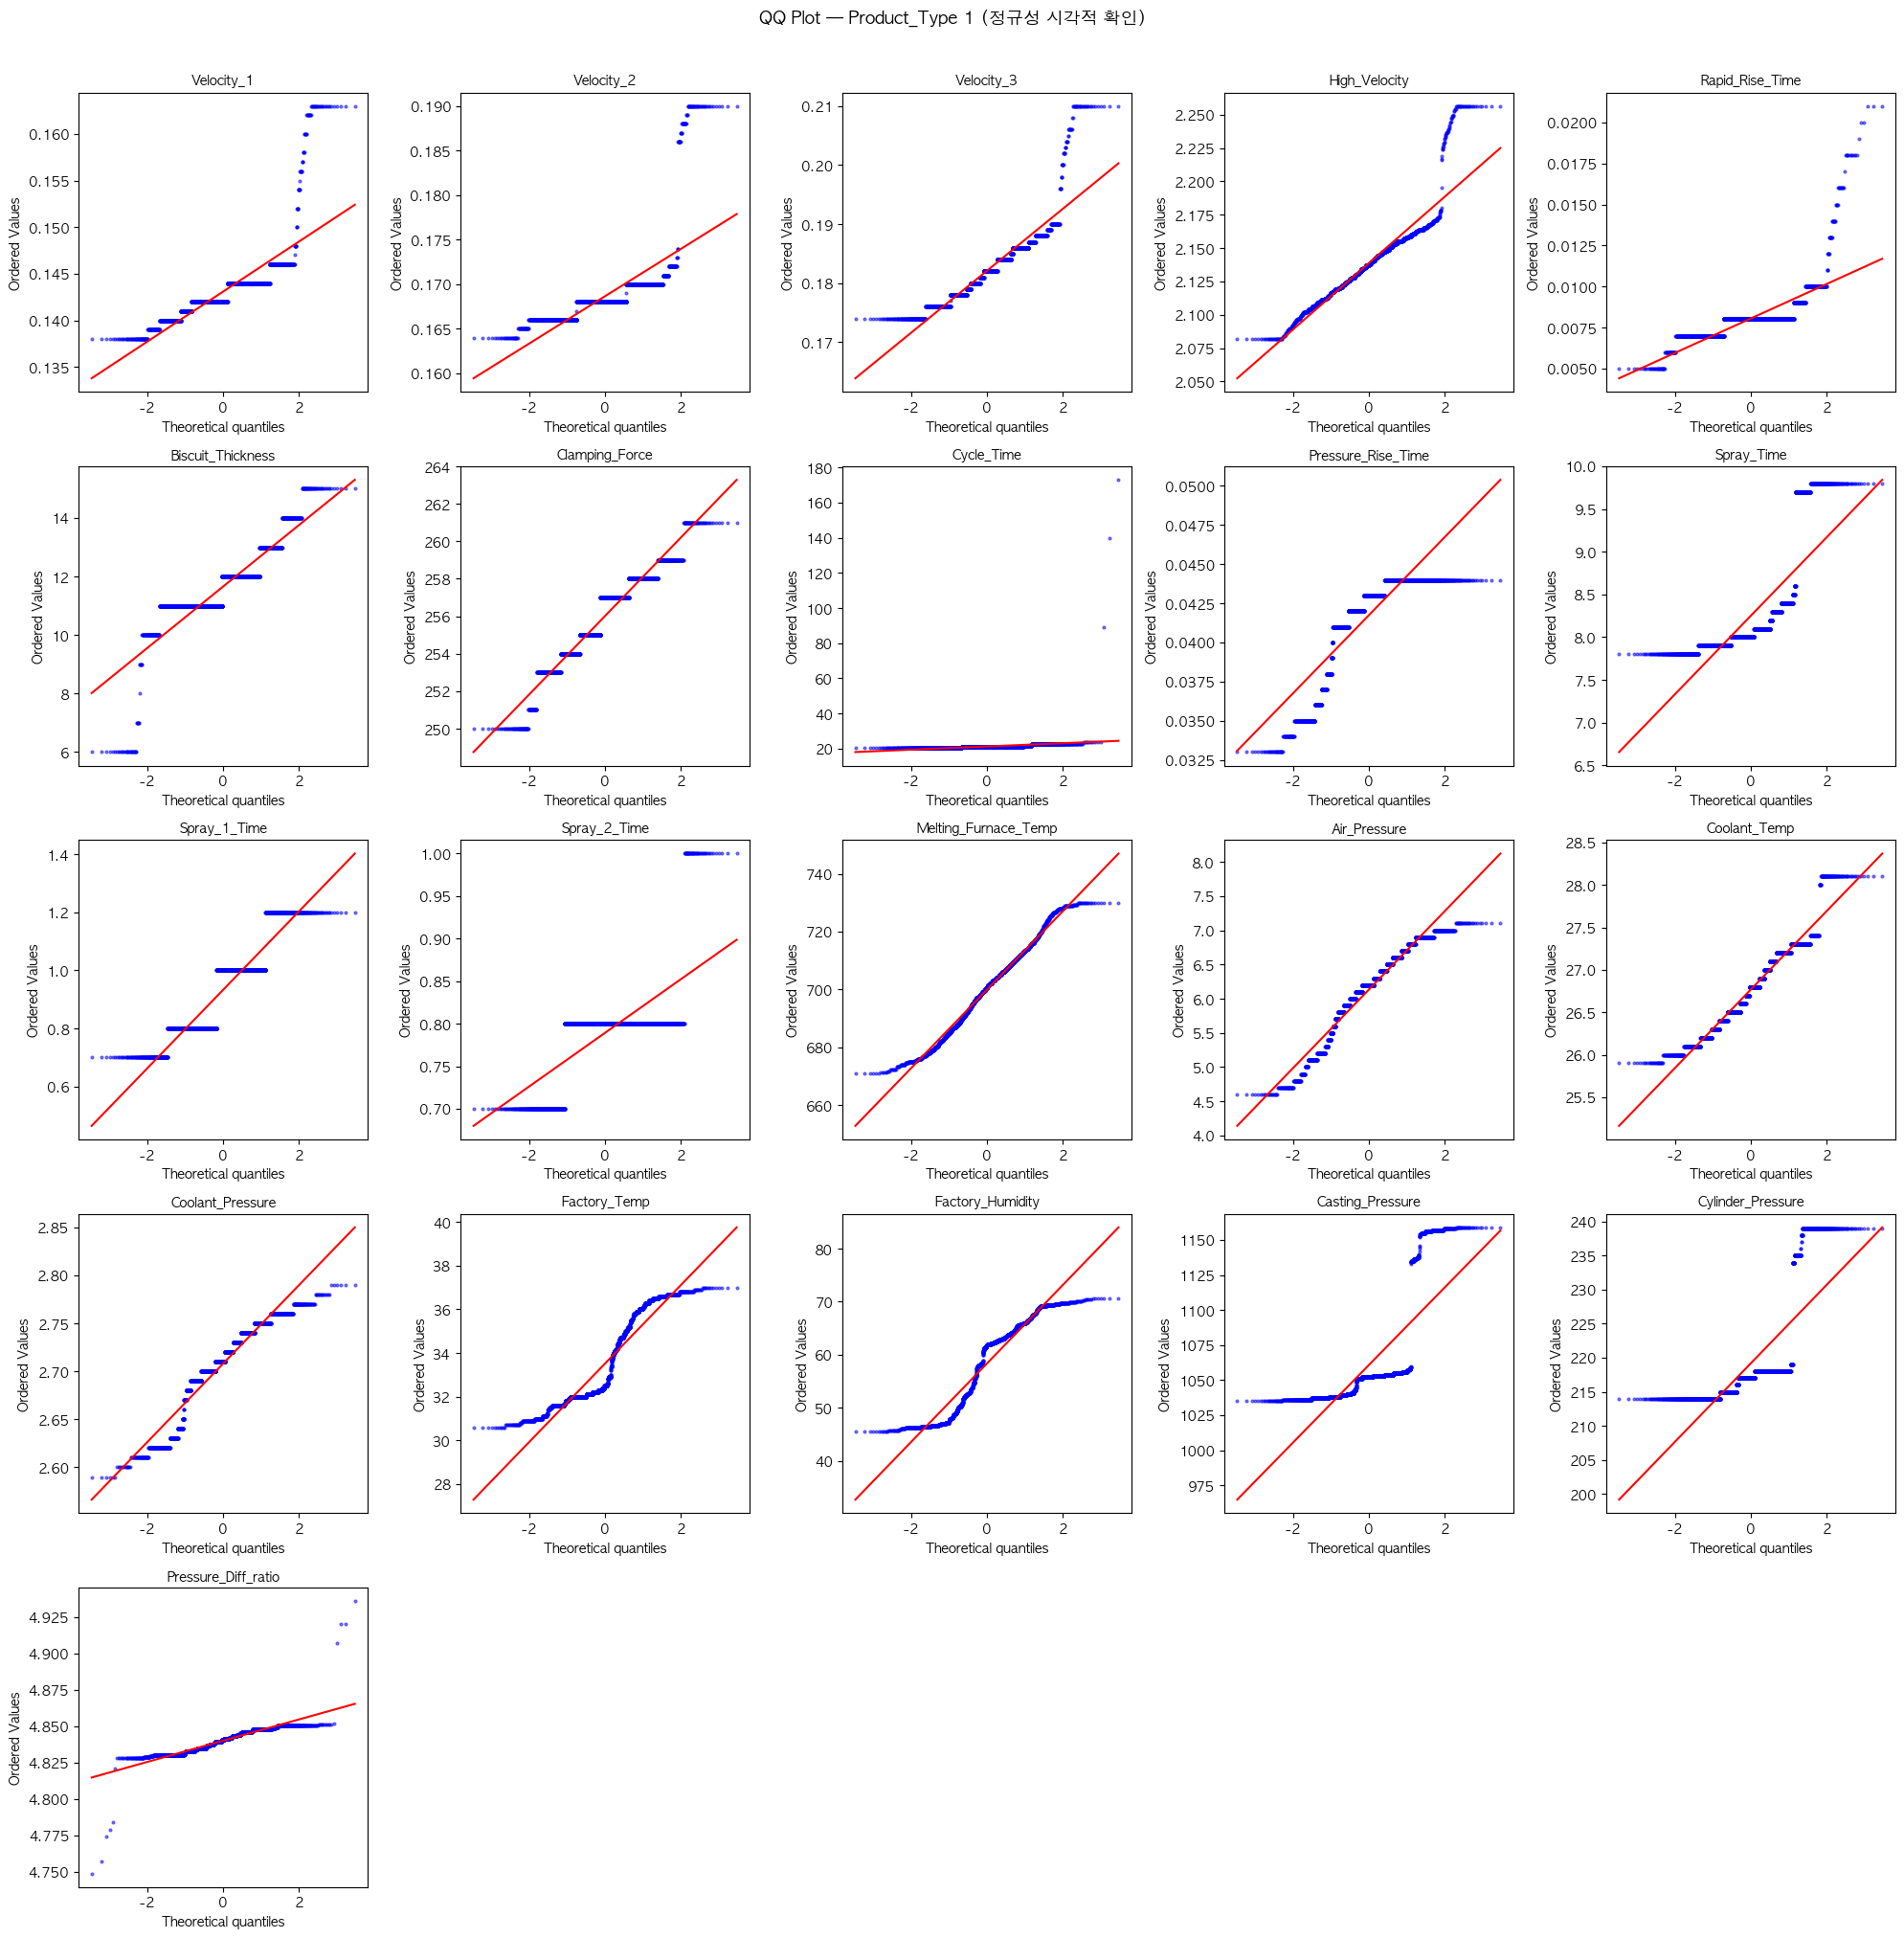

In [66]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(target_vars)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type1_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [67]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type1_df[type1_df['Defect_Status'] == 1]
normal   = type1_df[type1_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
#print(result_df.to_string(index=False))
display(pd.DataFrame(results))

,변수,U통계량,p-value,유의성
0,Velocity_1,616704.5,0.2196,❌
1,Velocity_2,565769.0,0.0353,✅
2,Velocity_3,575063.5,0.1632,❌
3,High_Velocity,658196.0,0.0002,✅
4,Rapid_Rise_Time,624281.5,0.0557,❌
5,Biscuit_Thickness,464937.0,0.0000,✅
6,Clamping_Force,663006.5,0.0000,✅
7,Cycle_Time,498077.5,0.0000,✅
8,Pressure_Rise_Time,679238.0,0.0000,✅
9,Spray_Time,517802.5,0.0000,✅


In [68]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type1_df[type1_df['Defect_Status'] == 1]
normal = type1_df[type1_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
display(pd.DataFrame(results))

,변수,p-value,효과크기(r),해석
0,Velocity_1,0.2196,0.0320,소
1,Velocity_2,0.0353,0.0533,소
2,Velocity_3,0.1632,0.0377,소
3,High_Velocity,0.0002,0.1014,소
4,Rapid_Rise_Time,0.0557,0.0446,소
5,Biscuit_Thickness,0.0000,0.2220,소
6,Clamping_Force,0.0000,0.1094,소
7,Cycle_Time,0.0000,0.1665,소
8,Pressure_Rise_Time,0.0000,0.1366,소
9,Spray_Time,0.0000,0.1335,소


In [69]:
#-------------------------------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type별 차이
#-------------------------------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
display(pd.DataFrame(results))

,변수,H통계량,p-value,유의성
0,Velocity_1,5.79,0.2154,❌
1,Velocity_2,9.23,0.0555,❌
2,Velocity_3,5.48,0.2411,❌
3,High_Velocity,22.03,0.0002,✅
4,Rapid_Rise_Time,6.04,0.1963,❌
5,Biscuit_Thickness,76.22,0.0000,✅
6,Clamping_Force,20.43,0.0004,✅
7,Cycle_Time,44.95,0.0000,✅
8,Pressure_Rise_Time,30.76,0.0000,✅
9,Spray_Time,34.81,0.0000,✅


In [70]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal', 'Stain', 'Other']
n_total = len(type1_df)

target_vars_stat = [col for col in target_vars if col not in ['Defect_Status', 'Defect_Type']]

results = []
for col in target_vars_stat:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
display(result_df)

,변수,H통계량,p-value,ε²,해석
17,Factory_Humidity,276.71,0.0000,0.1044,중
16,Factory_Temp,224.09,0.0000,0.0846,중
5,Biscuit_Thickness,79.92,0.0000,0.0302,소
11,Spray_2_Time,74.29,0.0000,0.0280,소
14,Coolant_Temp,72.72,0.0000,0.0274,소
18,Casting_Pressure,47.68,0.0000,0.0180,소
15,Coolant_Pressure,45.85,0.0000,0.0173,소
7,Cycle_Time,45.68,0.0000,0.0172,소
19,Cylinder_Pressure,43.56,0.0000,0.0164,소
10,Spray_1_Time,38.46,0.0000,0.0145,소


In [71]:
#---------------------
# 6. 사후검정 (Dunn's Test)
#---------------------
from IPython.display import display
import scikit_posthocs as sp

defect_types_list = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Other', 'Stain', 'Normal']

final_vars_stat = [col for col in final_vars if col not in ['Defect_Status', 'Defect_Type']]

for col in final_vars_stat:
    print(f'\n--- {col} ---')
    
    dunn = sp.posthoc_dunn(
        type1_df[type1_df['Defect_Type'].isin(defect_types_list)],
        val_col=col,
        group_col='Defect_Type',
        p_adjust='bonferroni'
    )
    
    display(dunn.round(4))


--- Velocity_1 ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Deformation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Exfoliation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Normal,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Other,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Short_Shot,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Stain,1.0,1.0,1.0,1.0,1.0,1.0,1.0



--- Velocity_2 ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Deformation,1.0,1.0000,1.0,0.1493,1.0,0.9238,1.0
Exfoliation,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Normal,1.0,0.1493,1.0,1.0000,1.0,1.0000,1.0
Other,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Short_Shot,1.0,0.9238,1.0,1.0000,1.0,1.0000,1.0
Stain,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0



--- Velocity_3 ---


...

,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0000,0.3889,0.0262,0.0,1.0,0.2759,1.0
Deformation,0.3889,1.0000,0.0000,0.0,1.0,0.0000,1.0
Exfoliation,0.0262,0.0000,1.0000,0.0,1.0,1.0000,1.0
Normal,0.0000,0.0000,0.0000,1.0,1.0,0.0000,1.0
Other,1.0000,1.0000,1.0000,1.0,1.0,1.0000,1.0
Short_Shot,0.2759,0.0000,1.0000,0.0,1.0,1.0000,1.0
Stain,1.0000,1.0000,1.0000,1.0,1.0,1.0000,1.0



--- Velocity_minmax ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Deformation,1.0,1.0000,0.2427,0.0142,1.0,1.0000,1.0
Exfoliation,1.0,0.2427,1.0000,1.0000,1.0,0.4459,1.0
Normal,1.0,0.0142,1.0000,1.0000,1.0,0.0325,1.0
Other,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Short_Shot,1.0,1.0000,0.4459,0.0325,1.0,1.0000,1.0
Stain,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0



--- Pressure_Diff_ratio ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Deformation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Exfoliation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Normal,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Other,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Short_Shot,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Stain,1.0,1.0,1.0,1.0,1.0,1.0,1.0
